# Autoencodeur SNN pour la compression de spike trains (snnTorch)

Ce notebook accompagne deux fichiers Python organises comme un petit projet :

- **`model.py`** : la definition du modele (`SNNAutoencoder`, `SNNStack`, `SNNLayer`), independante de toute experience -- c'est ce que vous reutiliseriez dans un script d'entrainement, un autre notebook, etc.
- **`data.py`** : la generation de spike trains synthetiques **structures** (corrélés via K sources latentes), et le split train/test.
- **`utils.py`** : la distorsion de reconstruction (distance de van Rossum), la boucle d'entrainement, et les fonctions de visualisation.
- **ce notebook** : hyperparametres, entrainement, tests, et une section interactive pour jouer avec les parametres.

## Le pipeline (sans canal, pour l'instant)

```
x (D_in neurones, T pas de temps)
        |
   [ ENCODEUR SNN ]         <- plusieurs couches configurables
        |
z (D_bottleneck neurones, T pas de temps)     <-- la representation "bas debit"
        |
   [ DECODEUR SNN ]         <- symetrique de l'encodeur
        |
x_hat (D_in neurones, T pas de temps)          <-- la reconstruction
```

L'encodeur et le decodeur sont entraines **ensemble**, de bout en bout, pour minimiser une distorsion entre `x` et `x_hat`. Il n'y a **pas de canal de communication** insere entre les deux pour l'instant (voir la derniere section pour comment l'ajouter plus tard).

## Neurones et gradient

Chaque couche est un neurone spikant **snnTorch** (`Synaptic` par defaut, qui a un courant synaptique + un potentiel de membrane -- structurellement proche des traces `trace_ff`/`trace_fb` de votre modele GLM precedent). La fonction de spike (seuil, non-differentiable) est entrainee via un **surrogate gradient** (`snntorch.surrogate`, par defaut `atan()`), ce qui permet un entrainement standard par backpropagation-through-time (BPTT), sans REINFORCE.

## Combien de couches cachees ?

**Recommandation pour demarrer : 1 seule couche cachee** de chaque cote (encodeur : `D_in -> 16 -> D_bottleneck`, decodeur symetrique). Pour ce genre de tache de compression sur un signal synthetique de dimension modeste, une seule couche cachee suffit generalement a capturer les correlations entre neurones d'entree -- ajouter des couches supplementaires complique l'entrainement (le gradient doit traverser plus de couches x plus de pas de temps) sans forcement ameliorer la reconstruction. Le parametre `hidden_dims` est neanmoins entierement configurable (section 6) : essayez `()` (aucune couche cachee), `(16,)`, `(32, 16)`, etc.


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from snntorch import surrogate

from model import SNNAutoencoder
from data import generate_synthetic_spike_trains, train_test_split
from utils import (train_model, van_rossum_distance, exponential_filter,
                    plot_loss_curves, plot_reconstruction)

%matplotlib inline
torch.manual_seed(0)
np.random.seed(0)


## 1. Donnees synthetiques

On genere des spike trains **structures** : chaque exemple vient de `K` sources latentes continues (lissees dans le temps), et chacun des `D_in` neurones d'entree recoit une combinaison (rate-codee) de ces `K` sources. Plus `K` est petit devant `D_in`, plus il y a de redondance **spatiale** entre les `D_in` trains de spikes -- c'est exactement ce que l'encodeur doit apprendre a exploiter.

`D_bottleneck >= K` devrait permettre une reconstruction quasi-parfaite (au bruit d'echantillonnage Bernoulli pres) ; `D_bottleneck < K` force une perte d'information incompressible -- une illustration directe de la theorie rate-distortion.


In [3]:
# --- hyperparametres des donnees ---
D_in = 16      # nombre de neurones d'entree (= nombre de trains de spikes par exemple)
T = 20         # nombre de pas de temps
K = 3          # dimension latente "vraie" (nombre de sources independantes)
n_samples = 250
p_max = 0.5
seed_data = 0

spikes, latent, rates = generate_synthetic_spike_trains(
    n_samples=n_samples, D_in=D_in, T=T, K=K, p_max=p_max, seed=seed_data)
train_spikes, test_spikes = train_test_split(spikes, train_frac=0.8, seed=seed_data)

# on garde aussi le decoupage correspondant des "vrais" taux (utile section 5)
n = spikes.shape[0]
g = torch.Generator().manual_seed(seed_data)
idx = torch.randperm(n, generator=g)
n_train = int(0.8 * n)
test_rates = rates[idx[n_train:]]

print(f"{train_spikes.shape[0]} exemples d'entrainement, {test_spikes.shape[0]} de test, "
      f"D_in={D_in} neurones, T={T} pas de temps")
print(f"taux de spike moyen (donnees) : {spikes.mean().item():.3f}")


200 exemples d'entrainement, 50 de test, D_in=16 neurones, T=20 pas de temps
taux de spike moyen (donnees) : 0.274


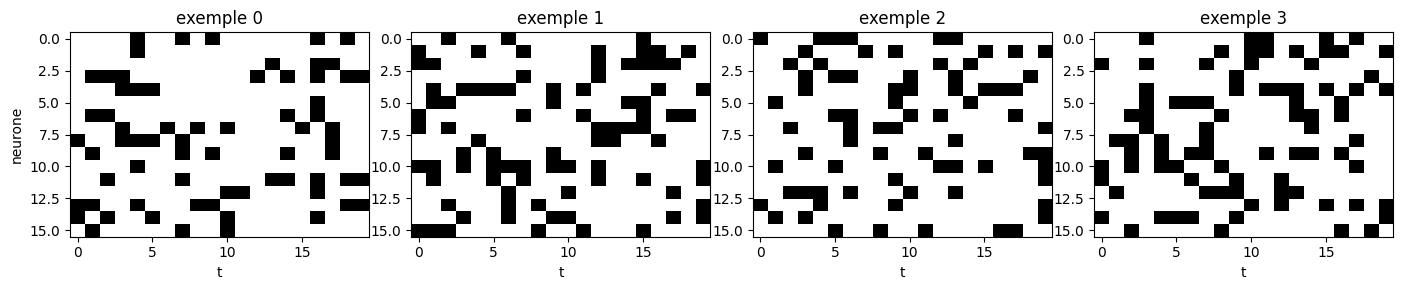

In [4]:
# quelques exemples de spike trains d'entree (rasters)
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i in range(4):
    axes[i].imshow(train_spikes[i].numpy().T, aspect="auto", cmap="Greys",
                   vmin=0, vmax=1, interpolation="nearest")
    axes[i].set_title(f"exemple {i}")
    axes[i].set_xlabel("t")
    axes[i].set_ylabel("neurone" if i == 0 else "")
plt.tight_layout()
plt.show()


## 2. Le modele : autoencodeur SNN

Voir `model.py` pour le detail de l'implementation (`SNNLayer`, `SNNStack`, `SNNAutoencoder`).


In [5]:
# --- hyperparametres du modele ---
D_bottleneck = 4        # taille du goulot z  (D_bottleneck < D_in => compression)
hidden_dims = (16,)     # couches cachees de l'encodeur (voir recommandation ci-dessus)
neuron = "synaptic"     # "synaptic" ou "leaky"
alpha, beta = 0.9, 0.9  # constantes de decroissance (courant synaptique / membrane)
threshold = 1.0
spike_grad = surrogate.atan()   # ou surrogate.straight_through_estimator(), etc.

model = SNNAutoencoder(D_in=D_in, D_bottleneck=D_bottleneck, hidden_dims=hidden_dims,
                        neuron=neuron, alpha=alpha, beta=beta, threshold=threshold,
                        spike_grad=spike_grad)

n_hidden_enc, n_hidden_dec = model.n_hidden_layers()
print(f"encodeur : {D_in} -> {' -> '.join(map(str, hidden_dims))} -> {D_bottleneck}  "
      f"({n_hidden_enc} couche(s) cachee(s))")
print(f"decodeur : {D_bottleneck} -> {' -> '.join(map(str, hidden_dims[::-1]))} -> {D_in}  "
      f"({n_hidden_dec} couche(s) cachee(s))")
print(f"ratio de compression (neurones) : {model.compression_ratio():.2f}")


encodeur : 16 -> 16 -> 4  (1 couche(s) cachee(s))
decodeur : 4 -> 16 -> 16  (1 couche(s) cachee(s))
ratio de compression (neurones) : 0.25


## 3. Entrainement (encodeur + decodeur ensemble, sans canal)

La loss est la **distance de van Rossum** entre `x` et `x_hat` (voir `utils.py`) : on filtre les deux trains de spikes par un noyau exponentiel puis on prend la MSE entre les traces filtrees. C'est beaucoup plus robuste qu'une MSE brute sur les 0/1, qui punirait severement un spike simplement decale d'un pas de temps.


epoch    0 | train loss 2.94937 | test loss 2.04394
epoch   30 | train loss 1.39250 | test loss 1.49155
epoch   60 | train loss 0.97588 | test loss 0.96555
epoch   90 | train loss 0.77884 | test loss 0.78760
epoch  120 | train loss 0.78545 | test loss 0.79842
epoch  149 | train loss 0.71498 | test loss 0.74932


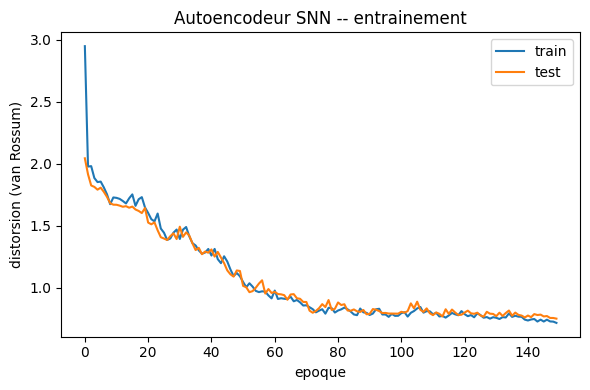

In [6]:
# --- hyperparametres d'entrainement ---
n_epochs = 150
lr = 1e-2
batch_size = 64
tau = 5.0   # constante de temps du filtre de van Rossum

torch.manual_seed(1)
train_losses, test_losses = train_model(
    model, train_spikes, test_spikes, n_epochs=n_epochs, lr=lr,
    batch_size=batch_size, tau=tau, verbose=True, print_every=30)

plot_loss_curves(train_losses, test_losses, title="Autoencodeur SNN -- entrainement")


## 4. Test : reconstruction visuelle

On compare, sur des exemples de test, le spike train d'entree et sa reconstruction.


taux de spike moyen -- x: 0.263 | z (bottleneck): 0.021 | x_hat: 0.243
distorsion de test (van Rossum) : 0.7493


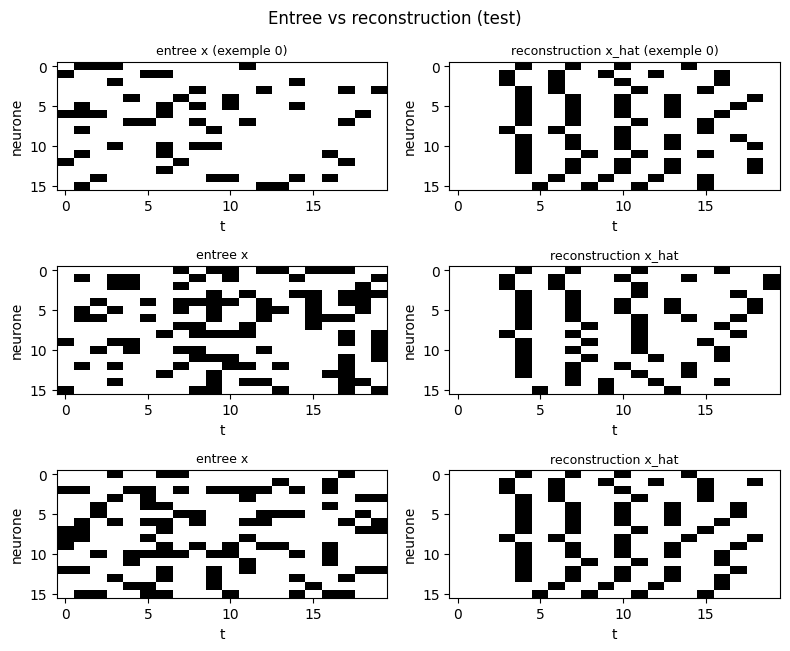

In [7]:
model.eval()
with torch.no_grad():
    z_test, x_hat_test = model(test_spikes)

print(f"taux de spike moyen -- x: {test_spikes.mean().item():.3f} | "
      f"z (bottleneck): {z_test.mean().item():.3f} | x_hat: {x_hat_test.mean().item():.3f}")
print(f"distorsion de test (van Rossum) : {van_rossum_distance(test_spikes, x_hat_test, tau=tau).item():.4f}")

plot_reconstruction(test_spikes, x_hat_test, n_show=3, title="Entree vs reconstruction (test)")


## 5. Courbe rate-distortion empirique : effet de `D_bottleneck`

On reentraine l'autoencodeur pour plusieurs tailles de goulot `D_bottleneck`, et on mesure la distorsion finale de deux facons :

- **par rapport a x** (le spike train observe) : cette distorsion a un plancher incompressible du au bruit d'echantillonnage Bernoulli intrinseque a la generation des donnees -- meme un decodeur parfait ne peut pas "deviner" exactement quelles cases ont spike parmi celles qui avaient la meme probabilite.
- **par rapport au "vrai" taux sous-jacent** (`rates`, avant le tirage Bernoulli) : celle-ci isole la qualite reelle de l'encodage, sans le bruit d'echantillonnage. C'est celle qui devrait saturer une fois que `D_bottleneck >= K` (la vraie dimension latente) -- **exactement la courbe R(D) que l'on cherche**.

Attention, cette cellule reentraine `n_epochs_sweep` modeles a partir de zero : elle prend une a quelques minutes.


D_bottleneck= 1 | distorsion vs x = 0.7463 | distorsion vs taux propre = 0.2241
D_bottleneck= 2 | distorsion vs x = 0.7811 | distorsion vs taux propre = 0.2452
D_bottleneck= 3 | distorsion vs x = 0.7978 | distorsion vs taux propre = 0.2797
D_bottleneck= 4 | distorsion vs x = 0.7487 | distorsion vs taux propre = 0.2249
D_bottleneck= 8 | distorsion vs x = 0.7139 | distorsion vs taux propre = 0.1922


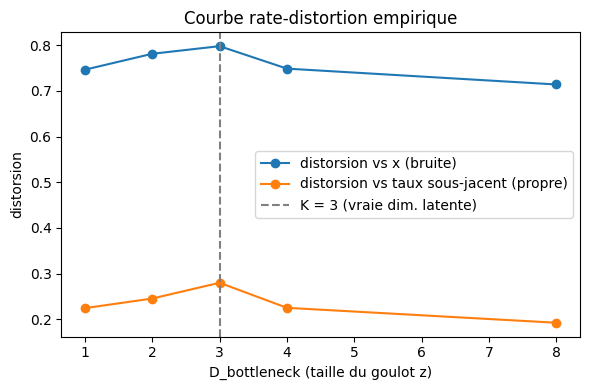

In [8]:
bottleneck_values = [1, 2, 3, 4, 8]
n_epochs_sweep = 300

dist_vs_x, dist_vs_rate = [], []
for Db in bottleneck_values:
    torch.manual_seed(0)
    m = SNNAutoencoder(D_in=D_in, D_bottleneck=Db, hidden_dims=hidden_dims,
                        neuron=neuron, alpha=alpha, beta=beta, threshold=threshold,
                        spike_grad=spike_grad)
    _, _ = train_model(m, train_spikes, test_spikes, n_epochs=n_epochs_sweep, lr=lr,
                        batch_size=batch_size, tau=tau, verbose=False)
    m.eval()
    with torch.no_grad():
        _, x_hat = m(test_spikes)
    d_x = van_rossum_distance(test_spikes, x_hat, tau=tau).item()
    trace_xhat = exponential_filter(x_hat, tau=tau)
    trace_rate = exponential_filter(test_rates, tau=tau)
    d_rate = torch.mean((trace_xhat - trace_rate) ** 2).item()
    dist_vs_x.append(d_x)
    dist_vs_rate.append(d_rate)
    print(f"D_bottleneck={Db:2d} | distorsion vs x = {d_x:.4f} | distorsion vs taux propre = {d_rate:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(bottleneck_values, dist_vs_x, "o-", label="distorsion vs x (bruite)")
plt.plot(bottleneck_values, dist_vs_rate, "o-", label="distorsion vs taux sous-jacent (propre)")
plt.axvline(K, color="grey", linestyle="--", label=f"K = {K} (vraie dim. latente)")
plt.xlabel("D_bottleneck (taille du goulot z)")
plt.ylabel("distorsion")
plt.title("Courbe rate-distortion empirique")
plt.legend()
plt.tight_layout()
plt.show()


**Lecture du graphe** : la courbe "vs x" reste au-dessus de zero meme pour un grand `D_bottleneck`, a cause du bruit d'echantillonnage Bernoulli intrinseque aux donnees (irreductible). La courbe "vs taux sous-jacent" devrait, elle, baisser nettement jusqu'a `D_bottleneck ≈ K` puis stagner : au-dela de la vraie dimension latente, ajouter des neurones au goulot n'apporte plus d'information utile a extraire -- exactement l'intuition rate-distortion dont on discutait (la partie plate de R(D) au-dela d'un certain point).


## 6. Interactif : jouer avec les parametres

Modifiez les parametres ci-dessous puis cliquez sur "Run Interact" pour reentrainer et revisualiser (les donnees restent celles generees en section 1).

- `hidden_dims_str` : tailles des couches cachees separees par des virgules (ex. `16`, `32,16`, ou laissez vide pour aucune couche cachee).


In [8]:
import ipywidgets as widgets
from ipywidgets import interact_manual

def parse_hidden_dims(s):
    s = s.strip()
    if not s:
        return ()
    return tuple(int(v) for v in s.split(",") if v.strip())

def run_experiment(D_bottleneck=4, hidden_dims_str="16", neuron="synaptic",
                    spike_grad_name="atan", n_epochs=150, lr=1e-2,
                    batch_size=64, tau=5.0, seed=0):
    hd = parse_hidden_dims(hidden_dims_str)
    spike_grad = {"atan": surrogate.atan(),
                  "fast_sigmoid": surrogate.fast_sigmoid(),
                  "straight_through": surrogate.straight_through_estimator()}[spike_grad_name]

    torch.manual_seed(seed)
    m = SNNAutoencoder(D_in=D_in, D_bottleneck=D_bottleneck, hidden_dims=hd,
                        neuron=neuron, alpha=alpha, beta=beta, threshold=threshold,
                        spike_grad=spike_grad)
    n_hid_enc, n_hid_dec = m.n_hidden_layers()
    print(f"encodeur avec {n_hid_enc} couche(s) cachee(s), ratio de compression "
          f"= {m.compression_ratio():.2f}")

    train_losses, test_losses = train_model(
        m, train_spikes, test_spikes, n_epochs=int(n_epochs), lr=lr,
        batch_size=int(batch_size), tau=tau, verbose=True, print_every=max(int(n_epochs)//5, 1))

    plot_loss_curves(train_losses, test_losses, title="Entrainement (interactif)")

    m.eval()
    with torch.no_grad():
        z_t, x_hat_t = m(test_spikes)
    print(f"distorsion finale de test : {van_rossum_distance(test_spikes, x_hat_t, tau=tau).item():.4f}")
    plot_reconstruction(test_spikes, x_hat_t, n_show=3, title="Entree vs reconstruction (interactif)")
    return m

_ = interact_manual(
    run_experiment,
    D_bottleneck=widgets.IntSlider(min=1, max=D_in, step=1, value=4),
    hidden_dims_str=widgets.Text(value="16"),
    neuron=widgets.Dropdown(options=["synaptic", "leaky"], value="synaptic"),
    spike_grad_name=widgets.Dropdown(options=["atan", "fast_sigmoid", "straight_through"], value="atan"),
    n_epochs=widgets.IntSlider(min=20, max=400, step=20, value=150),
    lr=widgets.FloatLogSlider(min=-4, max=-1, step=0.1, value=-2, base=10),
    batch_size=widgets.IntSlider(min=8, max=200, step=8, value=64),
    tau=widgets.FloatSlider(min=1.0, max=15.0, step=0.5, value=5.0),
    seed=widgets.IntSlider(min=0, max=20, step=1, value=0),
)


interactive(children=(IntSlider(value=4, description='D_bottleneck', max=16, min=1), Text(value='16', continuo…

## 7. Pour aller plus loin

- **Ajouter le canal de communication** : pour l'instant `z` passe directement de l'encodeur au decodeur. Pour simuler un *timing channel*, il suffit d'inserer une fonction entre `self.encoder(x)` et `self.decoder(z)` dans `SNNAutoencoder.forward` qui perturbe `z` (jitter aleatoire sur les temps de spike, deletion aleatoire de spikes, etc.) -- a condition que cette perturbation reste differentiable (ou approchee par un surrogate) pour continuer a entrainer de bout en bout.
- **Revenir a un neurone GLM probabiliste** (a la Jang et al., comme dans votre premier notebook) plutot que les neurones deterministes + surrogate gradient de snnTorch : il faudrait alors gerer le tirage stochastique du goulot avec un straight-through estimator ou un REINFORCE (voir discussion precedente) -- `snntorch.surrogate.straight_through_estimator()` peut directement s'inserer dans une couche GLM maison a cet effet.
- **Comparer a un dictionnaire sparse (Spiking-LCA)** : remplacer le goulot dense par une couche recurrente a inhibition laterale forcant explicitement la parcimonie (peu de neurones actifs a la fois), pour un compromis rate/distortion different de la simple reduction de dimension.
